<a href="https://colab.research.google.com/github/Chrisini/cosci-pygeon/blob/master/retinal-vessel-segmentation-unlabelled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ℝ𝕖𝕥𝕚𝕟𝕒𝕝 𝕍𝕖𝕤𝕤𝕖𝕝 𝕊𝕖𝕘𝕞𝕖𝕟𝕥𝕒𝕥𝕚𝕠𝕟

Inspiration from:
- https://github.com/Brains-for-hire/bcosfire_python/blob/main/cosfire/cosfire.py

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Load dataset

In [5]:
try:
    import medmnist
    from medmnist import INFO
except:
    !pip install medmnist
from torchvision import transforms

# choose dataset
data_flag = 'retinamnist'  # e.g. 'bloodmnist', 'tissuemnist', etc.

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# load datasets
train_dataset = DataClass(split='train', transform=transform, download=True, size=224)
val_dataset   = DataClass(split='val', transform=transform, download=True, size=224)
test_dataset  = DataClass(split='test', transform=transform, download=True, size=224)

print(train_dataset)
print(len(train_dataset))

100%|██████████| 128M/128M [00:03<00:00, 37.2MB/s]


Dataset RetinaMNIST of size 224 (retinamnist_224)
    Number of datapoints: 1080
    Root location: /root/.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0
1080


In [6]:
# first image
img, label = train_dataset[5]

img = np.array(img)

# [-1, 1] → [0, 1]
img = (img + 1) / 2.0

# [0, 1] → [0, 255]
img = (img * 255).astype(np.uint8)

img_o = img

print("Label:", label)
print("Shape:", img.shape)

Label: [0]
Shape: (3, 224, 224)


In [7]:
img

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)

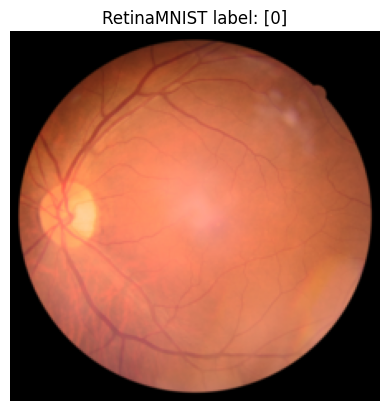

In [8]:
plt.imshow(np.transpose(img_o, (1, 2, 0)))
plt.title(f"RetinaMNIST label: {label}")
plt.axis("off")
plt.show()

# Segmentation
CLAHE + Frangi + postprocessing

(224, 224)
(224, 224)


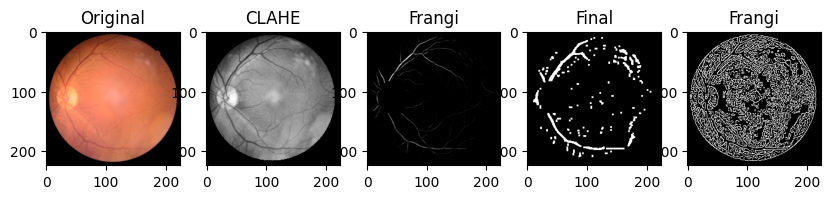

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi

img = img_o

# load image
img = cv2.cvtColor(np.transpose(img, (1, 2, 0)), cv2.COLOR_BGR2RGB)

# 1. green channel (important)
green = img[:, :, 1]



circles = cv2.HoughCircles(
    green,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=80,
    maxRadius=0
)

fundus = None
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    x, y, r = max(circles, key=lambda c: c[2])  # largest circle

    print(green.shape)
    mask = np.zeros(green.shape, dtype=np.uint8)
    cv2.circle(mask, (x, y), r, 255, -1)

    fundus = cv2.bitwise_and(green, green, mask=mask)

green = fundus



print(fundus.shape)

# 2. CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(green)



# 3. normalize to [0,1] for Frangi
norm = enhanced / 255.0


blur = cv2.GaussianBlur(norm, (51,51), 0)

norm = cv2.subtract(norm, blur)



# 4. Frangi vesselness
vessels = frangi(norm)



od_mask = (green > np.percentile(green[mask>0], 99)).astype(np.uint8)
od_mask = cv2.dilate(od_mask, np.ones((25,25)))

vessels[od_mask == 1] = 0

vessels[mask == 0] = 0

# 5. threshold
binary = (vessels > 0.001).astype(np.uint8)

# 6. postprocessing
kernel = np.ones((3,3), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# visualize
plt.figure(figsize=(10,4))
plt.subplot(1,5,1); plt.title("Original"); plt.imshow(np.transpose(img_o, (1, 2, 0)), cmap='gray')
plt.subplot(1,5,2); plt.title("CLAHE"); plt.imshow(enhanced, cmap='gray')
plt.subplot(1,5,3); plt.title("Frangi"); plt.imshow(vessels, cmap='gray')
plt.subplot(1,5,4); plt.title("Final"); plt.imshow(clean, cmap='gray')
plt.subplot(1,5,5); plt.title("Frangi"); plt.imshow(edges, cmap='gray')

plt.show()

In [56]:
print(np.unique(norm))

[-0.31926777 -0.31478388 -0.31013372 ...  0.32699948  0.33040747
  0.33209953]


In [10]:
img.shape

(224, 224, 3)

In [11]:
np.unique(img)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18